In [57]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path('/content/drive/MyDrive/Data') # Pass path to data folder here, e.g. Path('/content/drive/MyDrive/data') if using Google Drive
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
sks_df=pd.read_parquet(base_path / 'sks_users.parquet')
park_info_df=pd.read_parquet(base_path / 'parkings.parquet')
park_avaib_df=pd.read_parquet(base_path / 'parking_availabilities.parquet')
events_df=pd.read_parquet(base_path / 'pwr_events.parquet')


In [59]:
park_avaib_df.set_index('id', inplace=True)

In [60]:
sks_df.head()

,external_timestamp,active_users,moving_average_21,created_at,updated_at
0,2025-02-03 05:25:00+00:00,1,0,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00
1,2025-02-03 05:30:00+00:00,1,1,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00
2,2025-02-03 05:35:00+00:00,2,1,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00
3,2025-02-03 05:40:00+00:00,2,1,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00
4,2025-02-03 05:45:00+00:00,3,1,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00


Jak można zauważyć timestamp created_at i updated_at oznacza jedynie datę stworzenia wierszu i jego ostatnią aktualizację. Dane te są dla nas nieprzydatne.

In [61]:
sks_df=sks_df.drop(['created_at','updated_at'],axis=1)

In [62]:
sks_df.head()

,external_timestamp,active_users,moving_average_21
0,2025-02-03 05:25:00+00:00,1,0
1,2025-02-03 05:30:00+00:00,1,1
2,2025-02-03 05:35:00+00:00,2,1
3,2025-02-03 05:40:00+00:00,2,1
4,2025-02-03 05:45:00+00:00,3,1


In [63]:
park_info_df.head()

,id,symbol,type,name,open_hour,close_hour,places,geo_lan,geo_lat,is_active,is_visible,address,created_at,updated_at
0,7,E01,O,Architektura,06:00:00,22:30:00,75,17.054167,51.118736,True,True,"Bolesława Prusa 53/55, 50-317 Wrocław\r\n",2025-02-03 07:51:16.241000+00:00,2025-12-06 19:46:06.731000+00:00
1,4,WRO,O,Parking Wrońskiego,06:00:00,22:00:00,207,17.055565,51.108963,True,True,"Hoene-Wrońskiego 10, 50-376 Wrocław",2025-02-03 07:51:16.185000+00:00,2025-12-06 19:46:06.218000+00:00
2,2,C13,O,Polinka,None,None,54,17.058468,51.107390,True,True,"wybrzeże Stanisława Wyspiańskiego 25, 50-370 W...",2025-02-03 07:51:16.210000+00:00,2025-12-06 19:46:06.343000+00:00
3,5,D20,O,D20 - D21,06:00:00,22:30:00,76,17.059677,51.110050,True,True,"Janiszewskiego 8, 50-372 Wrocław\r\n",2025-02-03 07:51:16.222000+00:00,2025-12-06 19:46:06.478000+00:00
4,6,GEO-L,O,GEO LO1 Geocentrum,06:00:00,22:30:00,301,17.055334,51.104164,True,True,"Na Grobli 15, 50-421 Wrocław\r\n",2025-02-03 07:51:16.232000+00:00,2025-12-06 19:46:06.602000+00:00


W kontekście przewidywania ilości miejsc parkingowych nazwa, typ, adres i położenie geograficzne nie powinnny mieć znaczenia .W  przyszłości można dodać dodatkową zmienną, która zmienną binarną odpowiadająca, czy są jakieś wydarzenia w okolicy, np. konferencje w np. promieniu 1km. Jak na razie dodawanie jej mija się z celem z powodu braku danych. Is_active zostawię, zamierzam go wykorzystać do zaznaczania czy parking jest aktywny patrząc na godzinę pomiaru i to czy parking jest otwarty.

In [64]:
park_info_df=park_info_df.drop(['type','name','geo_lan','geo_lat','address','symbol'],axis=1)

In [65]:
park_info_df.head()

,id,open_hour,close_hour,places,is_active,is_visible,created_at,updated_at
0,7,06:00:00,22:30:00,75,True,True,2025-02-03 07:51:16.241000+00:00,2025-12-06 19:46:06.731000+00:00
1,4,06:00:00,22:00:00,207,True,True,2025-02-03 07:51:16.185000+00:00,2025-12-06 19:46:06.218000+00:00
2,2,None,None,54,True,True,2025-02-03 07:51:16.210000+00:00,2025-12-06 19:46:06.343000+00:00
3,5,06:00:00,22:30:00,76,True,True,2025-02-03 07:51:16.222000+00:00,2025-12-06 19:46:06.478000+00:00
4,6,06:00:00,22:30:00,301,True,True,2025-02-03 07:51:16.232000+00:00,2025-12-06 19:46:06.602000+00:00


In [66]:
park_avaib_df.head(10)

,parking_id,spaces_left,trend,measured_at,created_at,updated_at
id,,,,,,
1,4,0,0,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.203000+00:00,2025-02-03 07:51:16.203000+00:00
2,2,4,0,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.217000+00:00,2025-02-03 07:51:16.217000+00:00
3,5,0,0,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.228000+00:00,2025-02-03 07:51:16.228000+00:00
4,6,169,-2,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.237000+00:00,2025-02-03 07:51:16.237000+00:00
5,7,57,-1,2025-02-03 07:51:01+00:00,2025-02-03 07:51:16.246000+00:00,2025-02-03 07:51:16.246000+00:00
6,4,0,0,2025-02-03 07:54:01+00:00,2025-02-03 07:54:17.135000+00:00,2025-02-03 07:54:17.135000+00:00
7,2,4,0,2025-02-03 07:54:01+00:00,2025-02-03 07:54:17.144000+00:00,2025-02-03 07:54:17.144000+00:00
8,5,0,0,2025-02-03 07:54:01+00:00,2025-02-03 07:54:17.151000+00:00,2025-02-03 07:54:17.151000+00:00
9,6,164,-3,2025-02-03 07:54:01+00:00,2025-02-03 07:54:17.158000+00:00,2025-02-03 07:54:17.159000+00:00


In [67]:
park_avaib_df=park_avaib_df.drop(['created_at','updated_at'],axis=1)

In [68]:
park_info_df.head()

,id,open_hour,close_hour,places,is_active,is_visible,created_at,updated_at
0,7,06:00:00,22:30:00,75,True,True,2025-02-03 07:51:16.241000+00:00,2025-12-06 19:46:06.731000+00:00
1,4,06:00:00,22:00:00,207,True,True,2025-02-03 07:51:16.185000+00:00,2025-12-06 19:46:06.218000+00:00
2,2,None,None,54,True,True,2025-02-03 07:51:16.210000+00:00,2025-12-06 19:46:06.343000+00:00
3,5,06:00:00,22:30:00,76,True,True,2025-02-03 07:51:16.222000+00:00,2025-12-06 19:46:06.478000+00:00
4,6,06:00:00,22:30:00,301,True,True,2025-02-03 07:51:16.232000+00:00,2025-12-06 19:46:06.602000+00:00


In [69]:
sks_df.head()

,external_timestamp,active_users,moving_average_21
0,2025-02-03 05:25:00+00:00,1,0
1,2025-02-03 05:30:00+00:00,1,1
2,2025-02-03 05:35:00+00:00,2,1
3,2025-02-03 05:40:00+00:00,2,1
4,2025-02-03 05:45:00+00:00,3,1


In [70]:
events_df.head()

,uid,summary,start,end,location
0,64etqju29vmbvvmfnrdrdcbce1@google.com,Dzień Studenta na W-6,2023-11-17 00:00:00+00:00,2023-11-18 00:00:00+00:00,
1,6th3id9p68p6abb160s66b9k6gqmabb1c9i38bb3cphjeo...,[Studencka Dawka Kultury] Wyjście na Fantastyc...,2018-11-16 18:00:00+00:00,2018-11-16 21:00:00+00:00,
2,3molmc2sfn4jbhi8j55gjnrgfs@google.com,II Wrocławskie Studenckie Sympozjum Chemiczne...,2013-04-13 08:00:00+00:00,2013-04-13 16:00:00+00:00,
3,cdh3ec9pcpj30b9l74p6ab9k6oo3ibb16ss38bb568rj2c...,ATP,2019-10-15 00:00:00+00:00,2019-10-17 00:00:00+00:00,
4,5e5mi83jagqmb7iarfb593pmjh@google.com,Mikołajki W7 - cukierki na kampusie,2017-12-06 00:00:00+00:00,2017-12-07 00:00:00+00:00,


In [71]:
events_df=events_df.drop(['uid'],axis=1)

In [72]:
park_avaib_df.head()

,parking_id,spaces_left,trend,measured_at
id,,,,
1,4,0,0,2025-02-03 07:51:01+00:00
2,2,4,0,2025-02-03 07:51:01+00:00
3,5,0,0,2025-02-03 07:51:01+00:00
4,6,169,-2,2025-02-03 07:51:01+00:00
5,7,57,-1,2025-02-03 07:51:01+00:00


Jak widać mamy dane parkingów do 2025-02-03, zatem możemy obciąć dane z eventami, ponieważ jedynie będą nam spowalniać proces EDA.

In [73]:
events_df=events_df.sort_values(by='start')

In [74]:
events_df.dtypes

,0
summary,object
start,"datetime64[ns, UTC]"
end,"datetime64[ns, UTC]"
location,object


In [75]:
data_graniczna=pd.to_datetime("2025-02-03 07:51:01+00:00")
events_df = events_df[
    events_df['end'] >= data_graniczna
].copy()

In [76]:
def count_active_events(dataframe, dataframe1):
    for start, end in zip(starts, ends):
        if start <= current_time < end:
            count += 1

    return count


In [77]:
starts = events_df['start'].tolist()
ends = events_df['end'].tolist()
def count_active_events(current_time):
    count = 0

    for start, end in zip(starts, ends):
        if start <= current_time < end:
            count += 1

    return count

park_avaib_df['active_events'] = park_avaib_df['measured_at'].apply(count_active_events)

Następnie dodam jeszcze zmienną sprawdzającą, czy parking jest otwarty na podstawie godzin otwarcia.

In [78]:
park_info_df.head()

,id,open_hour,close_hour,places,is_active,is_visible,created_at,updated_at
0,7,06:00:00,22:30:00,75,True,True,2025-02-03 07:51:16.241000+00:00,2025-12-06 19:46:06.731000+00:00
1,4,06:00:00,22:00:00,207,True,True,2025-02-03 07:51:16.185000+00:00,2025-12-06 19:46:06.218000+00:00
2,2,None,None,54,True,True,2025-02-03 07:51:16.210000+00:00,2025-12-06 19:46:06.343000+00:00
3,5,06:00:00,22:30:00,76,True,True,2025-02-03 07:51:16.222000+00:00,2025-12-06 19:46:06.478000+00:00
4,6,06:00:00,22:30:00,301,True,True,2025-02-03 07:51:16.232000+00:00,2025-12-06 19:46:06.602000+00:00


Zmieniam nazwę kolumny ID, żeby mieć te same nazwy i było prościej

In [79]:
park_info_df.rename(columns={'id': 'parking_id'}, inplace=True)

In [80]:
park_info_df.dtypes

,0
parking_id,int64
open_hour,object
close_hour,object
places,int64
is_active,bool
is_visible,bool
created_at,"datetime64[ns, UTC]"
updated_at,"datetime64[ns, UTC]"


In [81]:
format_godziny = '%H:%M:%S'

park_info_df['open_hour'] = pd.to_datetime(park_info_df['open_hour'], format=format_godziny)
park_info_df['close_hour'] = pd.to_datetime(park_info_df['close_hour'], format=format_godziny)
park_info_df['open_hour'] = park_info_df['open_hour'].dt.tz_localize('UTC')
park_info_df['close_hour'] = park_info_df['close_hour'].dt.tz_localize('UTC')

In [82]:
park_info_df.dtypes

,0
parking_id,int64
open_hour,"datetime64[ns, UTC]"
close_hour,"datetime64[ns, UTC]"
places,int64
is_active,bool
is_visible,bool
created_at,"datetime64[ns, UTC]"
updated_at,"datetime64[ns, UTC]"


In [83]:
park_avaib_df.dtypes

,0
parking_id,int64
spaces_left,int64
trend,int64
measured_at,"datetime64[ns, UTC]"
active_events,int64


In [84]:
harmonogram_parkingow = park_info_df.set_index('parking_id').to_dict('index')

In [85]:
import pandas as pd

def sprawdz_czy_parking_otwarty(row):
    current_parking_id = row['parking_id']
    if current_parking_id not in harmonogram_parkingow:
        return 0

    harmonogram = harmonogram_parkingow[current_parking_id]
    otwarcie = harmonogram['open_hour']
    zamkniecie = harmonogram['close_hour']
    current_time = row['measured_at'].time()

    # Check if both open and close hours are Not a Time (NaT)
    if pd.isna(otwarcie) and pd.isna(zamkniecie):
        return 1 # Assume open if hours are not specified

    # Ensure both opening and closing times are valid before comparison
    if not pd.isna(otwarcie) and not pd.isna(zamkniecie):
        # Compare only the time components
        if otwarcie.time() <= current_time < zamkniecie.time():
            return 1
        else:
            return 0
    else:
        # If one is NaT and the other is not (or other edge cases), consider it closed
        return 0

In [86]:
park_avaib_df['isOpen'] = park_avaib_df.apply(sprawdz_czy_parking_otwarty, axis=1)

In [87]:
park_avaib_df['isOpen'].unique()

array([1, 0])

Jak widać mamy dane, gdy parking jest zamknięty oraz otwarty.

In [88]:
park_avaib_df.head()

,parking_id,spaces_left,trend,measured_at,active_events,isOpen
id,,,,,,
1,4,0,0,2025-02-03 07:51:01+00:00,0,1
2,2,4,0,2025-02-03 07:51:01+00:00,0,1
3,5,0,0,2025-02-03 07:51:01+00:00,0,1
4,6,169,-2,2025-02-03 07:51:01+00:00,0,1
5,7,57,-1,2025-02-03 07:51:01+00:00,0,1


In [89]:
sks_df.head()

,external_timestamp,active_users,moving_average_21
0,2025-02-03 05:25:00+00:00,1,0
1,2025-02-03 05:30:00+00:00,1,1
2,2025-02-03 05:35:00+00:00,2,1
3,2025-02-03 05:40:00+00:00,2,1
4,2025-02-03 05:45:00+00:00,3,1


In [90]:
sks_df=sks_df.set_index('external_timestamp')
sks_df.index = sks_df.index.round('min')

In [91]:
sks_df=sks_df.resample('1min').ffill()

In [92]:
sks_df.tail()

,active_users,moving_average_21
external_timestamp,,
2025-12-06 22:51:00+00:00,0,10
2025-12-06 22:52:00+00:00,0,10
2025-12-06 22:53:00+00:00,0,10
2025-12-06 22:54:00+00:00,0,10
2025-12-06 22:55:00+00:00,0,10


In [93]:
park_avaib_df=park_avaib_df.set_index('measured_at')
park_avaib_df.index = park_avaib_df.index.round('min')
ostatni_wspolny_moment = sks_df.index.max()
park_avaib_df = park_avaib_df[park_avaib_df.index <= ostatni_wspolny_moment]
park_avaib_df=park_avaib_df.join(sks_df,how='left')
park_avaib_df.reset_index(inplace=True)

In [94]:
park_avaib_df.tail()

,measured_at,parking_id,spaces_left,trend,active_events,isOpen,active_users,moving_average_21
1822324,2025-12-06 22:55:00+00:00,4,193,0,3,0,0,10
1822325,2025-12-06 22:55:00+00:00,2,43,0,3,1,0,10
1822326,2025-12-06 22:55:00+00:00,5,29,0,3,0,0,10
1822327,2025-12-06 22:55:00+00:00,6,263,0,3,0,0,10
1822328,2025-12-06 22:55:00+00:00,7,84,0,3,0,0,10


In [95]:
park_avaib_df['day_of_week'] = park_avaib_df['measured_at'].dt.dayofweek
park_avaib_df['is_weekend'] = park_avaib_df['day_of_week'].isin([5, 6])

In [96]:
df_miejsca = park_info_df[['parking_id', 'places']]

park_avaib_df = pd.merge(
    park_avaib_df,
    df_miejsca,
    on='parking_id',
    how='left'
)

park_avaib_df.rename(columns={'places': 'spaces'}, inplace=True)
park_avaib_df.head(10)

,measured_at,parking_id,spaces_left,trend,active_events,isOpen,active_users,moving_average_21,day_of_week,is_weekend,spaces
0,2025-02-03 07:51:00+00:00,4,0,0,0,1,12,10,0,False,207
1,2025-02-03 07:51:00+00:00,2,4,0,0,1,12,10,0,False,54
2,2025-02-03 07:51:00+00:00,5,0,0,0,1,12,10,0,False,76
3,2025-02-03 07:51:00+00:00,6,169,-2,0,1,12,10,0,False,301
4,2025-02-03 07:51:00+00:00,7,57,-1,0,1,12,10,0,False,75
5,2025-02-03 07:54:00+00:00,4,0,0,0,1,12,10,0,False,207
6,2025-02-03 07:54:00+00:00,2,4,0,0,1,12,10,0,False,54
7,2025-02-03 07:54:00+00:00,5,0,0,0,1,12,10,0,False,76
8,2025-02-03 07:54:00+00:00,6,164,-3,0,1,12,10,0,False,301
9,2025-02-03 07:54:00+00:00,7,57,0,0,1,12,10,0,False,75


In [97]:
park_avaib_df.dtypes

,0
measured_at,"datetime64[ns, UTC]"
parking_id,int64
spaces_left,int64
trend,int64
active_events,int64
isOpen,int64
active_users,int64
moving_average_21,int64
day_of_week,int32
is_weekend,bool


In [98]:
park_avaib_df['active_users'].isna().sum()

np.int64(0)

In [99]:
park_avaib_df['hour'] = park_avaib_df['measured_at'].dt.hour

In [100]:
park_avaib_df['active_events'].unique()

array([0, 1, 2, 3, 4, 5, 6])

In [101]:
def eventsSpaces(df_input: pd.DataFrame):

  df_dane = df_input # Correctly assign the input DataFrame
  df_dane['godzina'] = df_dane['measured_at'].dt.hour # Use 'measured_at' from park_avaib_df

  df_srednia_godzinowa = (
      df_dane.groupby(['parking_id', 'active_events', 'hour']) # Use 'active_events' from park_avaib_df
      ['spaces_left'] # Use 'spaces_left' for available spaces
      .mean()
      .reset_index()
  )
  df_srednia_godzinowa['active_events'] = (
      df_srednia_godzinowa['active_events']
      .astype('category')
  )

  print("--- Fragment zagregowanych danych (ID, Eventy, Godzina, Średnia) ---")
  print(df_srednia_godzinowa.head())
  unikalne_parkingi = df_srednia_godzinowa['parking_id'].nunique()
  col_wrap_value = min(unikalne_parkingi, 3)

  g = sns.FacetGrid(
      df_srednia_godzinowa,
      col='parking_id',
      col_wrap=col_wrap_value,
      sharey=False,
      height=4
  )

  g.map(
      sns.lineplot,
      'hour',
      'spaces_left',
      'active_events',
      palette='viridis'
  )

  g.set_axis_labels("Godzina Dnia (0-23)", "Średnia Dostępna Ilość Miejsc")
  g.set_titles(col_template="Parking ID: {col_name}")
  g.add_legend(title="Liczba Aktywnych Wydarzeń")

  plt.suptitle('Średnia Dostępność Miejsc Parkingowych w zależności od Godziny i Aktywnych Wydarzeń', y=1.02)
  g.figure.tight_layout(w_pad=1)
  plt.show()
  return

In [102]:
def heatmap(df: pd.DataFrame, values_col: str, index_col: str, columns_col: str):
  pivot = df.pivot_table(values=values_col, index=index_col, columns=columns_col, aggfunc='mean')

  plt.figure(figsize=(12, 6))
  sns.heatmap(pivot, cmap='YlGnBu', annot=False)
  plt.title(f'Średnia wartość: {columns_col} vs {index_col}')
  plt.ylabel(index_col)
  plt.show()

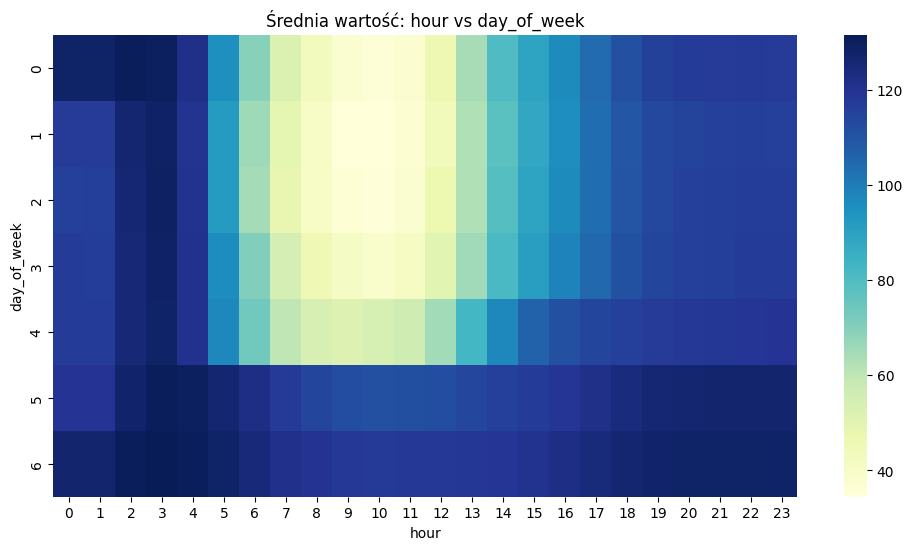

In [103]:
heatmap(park_avaib_df,"spaces_left","day_of_week","hour")

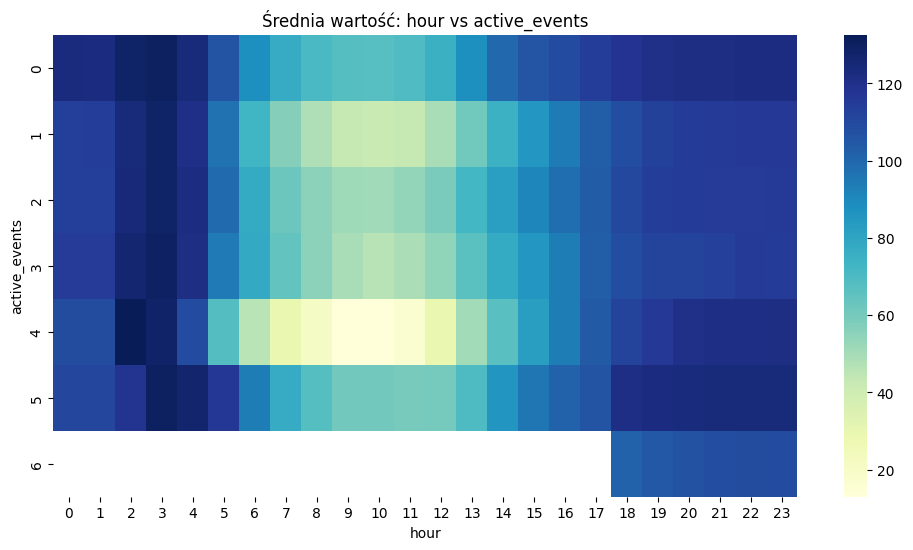

In [105]:
heatmap(park_avaib_df,"spaces_left","active_events","hour")

Jak można zauważyć, w piątki zwykle jest więcej miejsc niż w inne dni pracujące.

--- Fragment zagregowanych danych (ID, Eventy, Godzina, Średnia) ---
   parking_id active_events  hour  spaces_left
0           2             0     0    50.581966
1           2             0     1    50.412817
2           2             0     2    55.989166
3           2             0     3    54.805701
4           2             0     4    49.503120


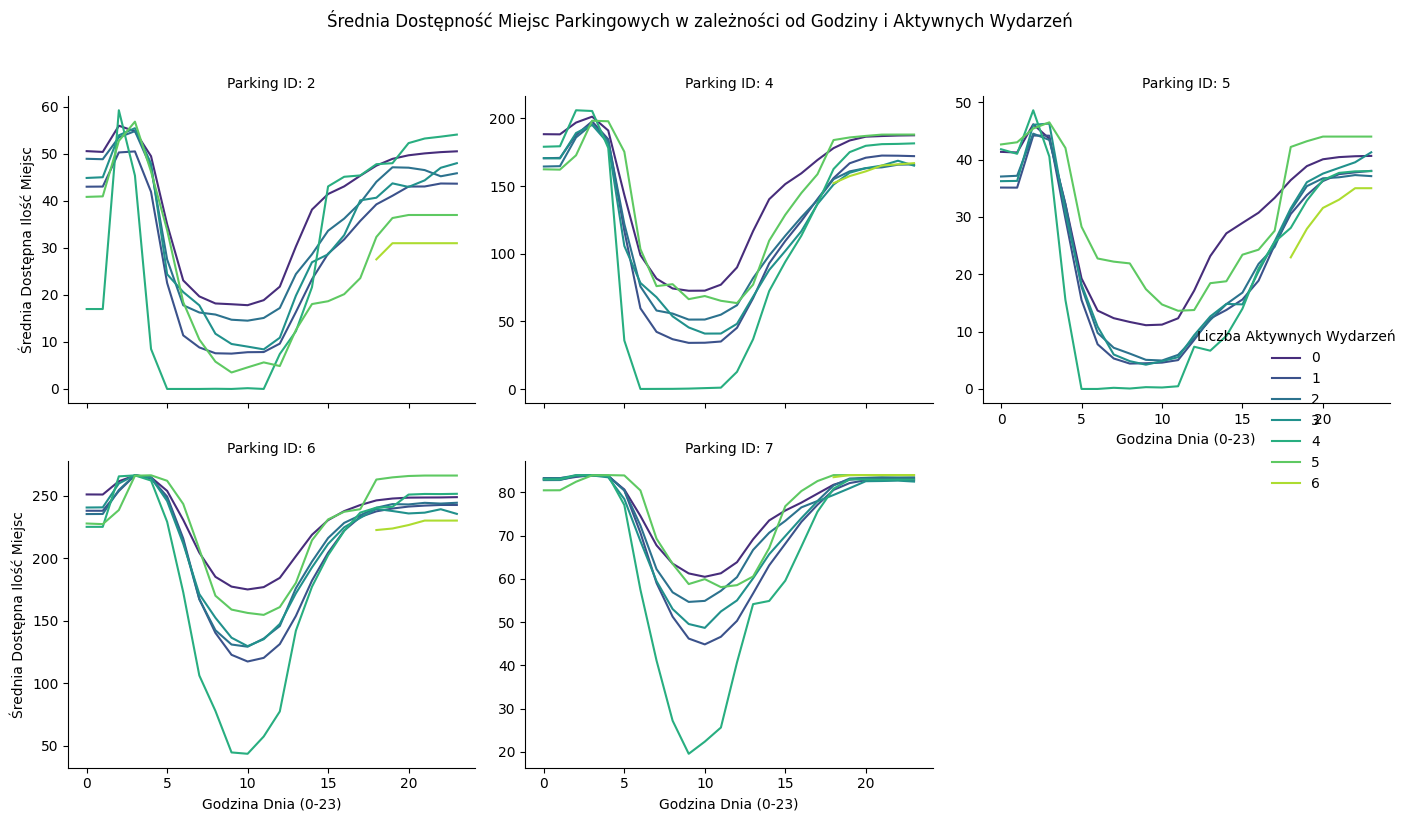

In [106]:
eventsSpaces(park_avaib_df)

In [107]:
park_avaib_df['lag_1'] = park_avaib_df['spaces_left'].shift(1)
park_avaib_df['lag_7'] = park_avaib_df['spaces_left'].shift(7)
park_avaib_df['lag_14'] = park_avaib_df['spaces_left'].shift(14)